In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import shap
import warnings
warnings.filterwarnings('ignore')

TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE  = 10
DPI        = 300

# ── Load base merged dataset (from 03-model.ipynb) ────────────────────────────
base = pd.read_csv('../data/processed/merged_gbd_gdp_2021.csv')
print(f'Base dataset: {base.shape[0]} countries')
print(base[['location_name', 'Country Code', 'val', 'log_gdp', 'residual']].head(5).to_string(index=False))

Base dataset: 166 countries
location_name Country Code       val  log_gdp  residual
     Thailand          THA 34.472342 9.915553 13.652980
  Philippines          PHL 15.952341 9.089053  1.286076
  Timor-Leste          TLS 12.331008 8.828354 -0.394421
    Indonesia          IDN 20.391509 9.453841  3.009480
     Viet Nam          VNM 19.874778 9.396729  2.917937


In [2]:
# ── Load Modality 6: Aging (World Bank SP.POP.65UP.TO.ZS) ─────────────────────
aging_csv = glob.glob('../data/raw/aging_65plus/API_SP*.csv')[0]
aging_raw = pd.read_csv(aging_csv, skiprows=4)

aging = aging_raw[['Country Code', '2021']].dropna(subset=['2021']).copy()
aging.columns = ['Country Code', 'pct_65plus']
print(f'Aging data: {len(aging)} countries')

# ── Load Modality 8: Obesity (WHO GHO NCD_BMI_30C, 2016) ──────────────────────
obesity_raw = pd.read_csv('../data/raw/who_obesity_2016.csv')
obesity = obesity_raw[['SpatialDim', 'NumericValue']].copy()
obesity.columns = ['Country Code', 'obesity_pct']
print(f'Obesity data: {len(obesity)} countries')

# ── Load Modality 4: FAO Food (if downloaded) ──────────────────────────────────
fao_available = False
try:
    fao_files = glob.glob('../data/raw/FAOSTAT*.csv')
    if fao_files:
        fao_raw = pd.read_csv(fao_files[0])
        fao_2021 = fao_raw[fao_raw['Year'] == 2021].copy()
        fao_pivot = fao_2021.pivot_table(
            index='Area',
            columns='Item',
            values='Value'
        ).reset_index()
        fao_pivot.columns.name = None
        fao_available = True
        print(f'FAO data loaded: {len(fao_pivot)} areas')
        print('FAO items:', [c for c in fao_pivot.columns if c != 'Area'])
    else:
        print('FAO data not found — skipping Modality 4.')
        print('Download from: https://www.fao.org/faostat/en/#data/FBS')
except Exception as e:
    print(f'FAO load error: {e}')

Aging data: 265 countries
Obesity data: 199 countries
FAO data not found — skipping Modality 4.
Download from: https://www.fao.org/faostat/en/#data/FBS


In [3]:
# ── Merge all modalities ───────────────────────────────────────────────────────
merged = base.merge(aging, on='Country Code', how='left')
merged = merged.merge(obesity, on='Country Code', how='left')

if fao_available:
    # FAO uses country names, not ISO codes — approximate name match
    merged = merged.merge(fao_pivot, left_on='location_name', right_on='Area', how='left')

print('After merging all modalities:')
print(f'  Total rows: {len(merged)}')
print(f'  pct_65plus available: {merged["pct_65plus"].notna().sum()}')
print(f'  obesity_pct available: {merged["obesity_pct"].notna().sum()}')

# Georgia check
geo = merged[merged['location_name'] == 'Georgia'][['location_name','val','log_gdp','pct_65plus','obesity_pct','residual']]
print('\nGeorgia:')
print(geo.to_string(index=False))

After merging all modalities:
  Total rows: 166
  pct_65plus available: 166
  obesity_pct available: 165

Georgia:
location_name       val  log_gdp  pct_65plus  obesity_pct  residual
      Georgia 77.167718 9.847745   14.988844    33.430311 56.853169
      Georgia 19.696542 9.847745   14.988844    33.430311 -0.618007


In [4]:
# ── Progressive regression: compare R² as we add modalities ───────────────────
results = []

model_specs = [
    ('M1: GDP only (baseline)',          ['log_gdp']),
    ('M2: GDP + Aging',                  ['log_gdp', 'pct_65plus']),
    ('M3: GDP + Aging + Obesity',        ['log_gdp', 'pct_65plus', 'obesity_pct']),
]

for name, features in model_specs:
    df_m = merged[features + ['val']].dropna()
    X = df_m[features]
    y = df_m['val']
    m = LinearRegression().fit(X, y)
    r2 = m.score(X, y)
    n = len(df_m)
    coefs = dict(zip(features, m.coef_))
    results.append({'Model': name, 'N countries': n, 'R²': round(r2, 3), **coefs})
    print(f'{name}')
    print(f'  N={n}, R²={r2:.3f}')
    for feat, coef in zip(features, m.coef_):
        print(f'  {feat}: {coef:.3f}')
    print()

results_df = pd.DataFrame(results)
print(results_df[['Model', 'N countries', 'R²']].to_string(index=False))

M1: GDP only (baseline)
  N=166, R²=0.386
  log_gdp: 7.445

M2: GDP + Aging
  N=166, R²=0.476
  log_gdp: 3.863
  pct_65plus: 0.854

M3: GDP + Aging + Obesity
  N=165, R²=0.472
  log_gdp: 3.599
  pct_65plus: 0.862
  obesity_pct: 0.047

                    Model  N countries    R²
  M1: GDP only (baseline)          166 0.386
          M2: GDP + Aging          166 0.476
M3: GDP + Aging + Obesity          165 0.472


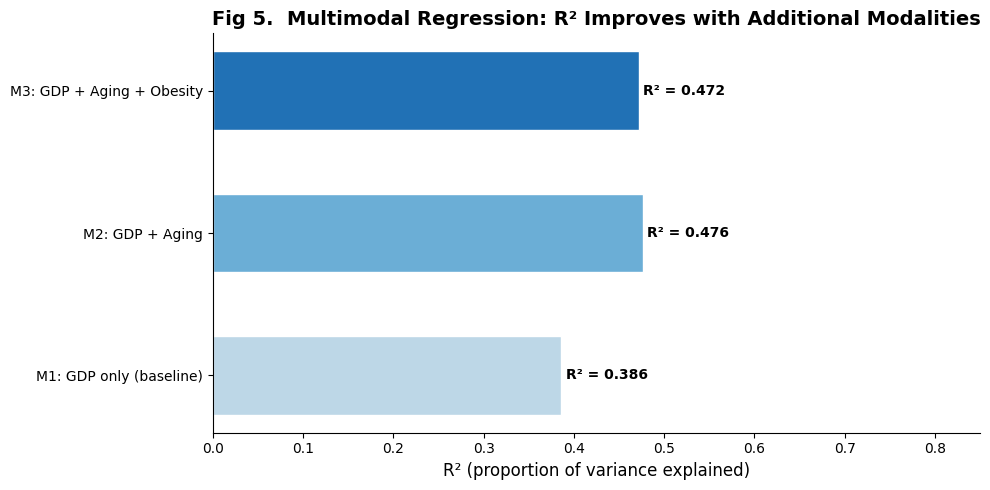

Saved: figures/fig5_r2_progression.png


In [5]:
# ── Fig 5: R² progression bar chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

labels = [r['Model'] for r in results]
r2_vals = [r['R²'] for r in results]
colors  = ['#bdd7e7', '#6baed6', '#2171b5']

bars = ax.barh(labels, r2_vals, color=colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, r2_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'R² = {val:.3f}', va='center', fontsize=TICK_SIZE, fontweight='bold')

ax.set_xlabel('R² (proportion of variance explained)', fontsize=LABEL_SIZE)
ax.set_title('Fig 5.  Multimodal Regression: R² Improves with Additional Modalities',
             fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlim(0, 0.85)
ax.tick_params(labelsize=TICK_SIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig5_r2_progression.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig5_r2_progression.png')

In [6]:
# ── Best model: GDP + Aging + Obesity ─────────────────────────────────────────
best_features = ['log_gdp', 'pct_65plus', 'obesity_pct']
df_best = merged[best_features + ['val', 'location_name']].dropna().copy()

X_best = df_best[best_features]
y_best = df_best['val']

model_best = LinearRegression().fit(X_best, y_best)
df_best['predicted_multi'] = model_best.predict(X_best)
df_best['residual_multi']  = df_best['val'] - df_best['predicted_multi']

print(f'Best model R²: {model_best.score(X_best, y_best):.3f}')
print(f'Baseline R²:   0.386')
print(f'R² improvement: +{model_best.score(X_best, y_best) - 0.386:.3f}')

# How much of Georgia residual does the multimodal model explain?
geo_multi = df_best[df_best['location_name'] == 'Georgia']
if not geo_multi.empty:
    print(f'\nGeorgia:')
    print(f'  Actual DALY:          {geo_multi["val"].values[0]:.1f}')
    print(f'  GDP-only prediction:  {merged.loc[merged["location_name"]=="Georgia", "predicted"].values[0]:.1f}')
    print(f'  Multi-modal prediction: {geo_multi["predicted_multi"].values[0]:.1f}')
    print(f'  Residual (GDP only):   {merged.loc[merged["location_name"]=="Georgia", "residual"].values[0]:.1f}')
    print(f'  Residual (multimodal): {geo_multi["residual_multi"].values[0]:.1f}')

Best model R²: 0.472
Baseline R²:   0.386
R² improvement: +0.086

Georgia:
  Actual DALY:          77.2
  GDP-only prediction:  20.3
  Multi-modal prediction: 24.6
  Residual (GDP only):   56.9
  Residual (multimodal): 52.6


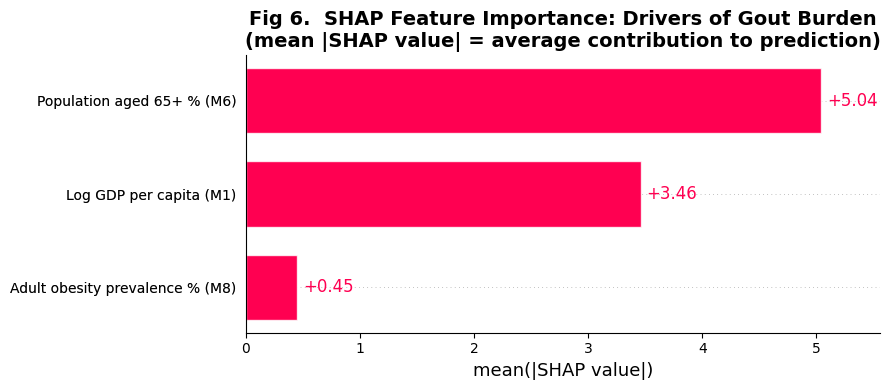

Saved: figures/fig6_shap.png


In [7]:
# ── SHAP: feature importance for the best model ────────────────────────────────
explainer   = shap.LinearExplainer(model_best, X_best)
shap_values = explainer(X_best)

fig, ax = plt.subplots(figsize=(9, 4))
shap.plots.bar(shap_values, show=False, ax=ax)

ax.set_title('Fig 6.  SHAP Feature Importance: Drivers of Gout Burden\n'
             '(mean |SHAP value| = average contribution to prediction)',
             fontsize=TITLE_SIZE, fontweight='bold')
ax.tick_params(labelsize=TICK_SIZE)

# Rename x-axis labels
labels_map = {
    'log_gdp':     'Log GDP per capita (M1)',
    'pct_65plus':  'Population aged 65+ % (M6)',
    'obesity_pct': 'Adult obesity prevalence % (M8)'
}
ax.set_yticklabels([labels_map.get(t.get_text(), t.get_text())
                    for t in ax.get_yticklabels()], fontsize=TICK_SIZE)

plt.tight_layout()
plt.savefig('../figures/fig6_shap.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig6_shap.png')

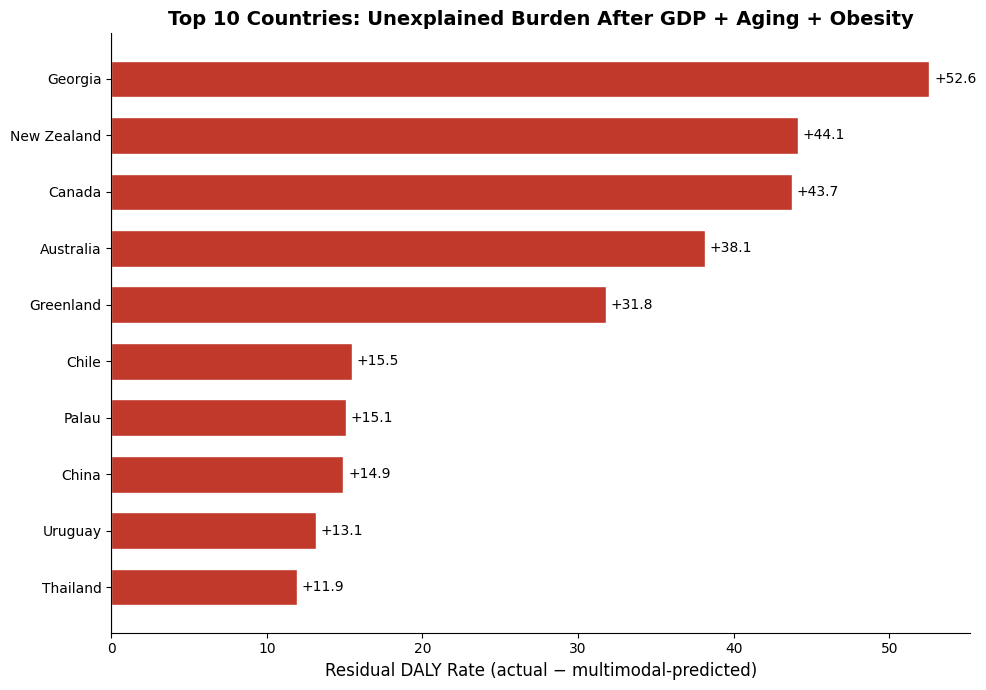

Saved: figures/fig7_residuals_multi.png

Top 10 unexplained countries (multimodal model):
location_name       val  predicted_multi  residual_multi
      Georgia 77.167718        24.599707       52.568010
  New Zealand 72.894783        28.798352       44.096431
       Canada 74.989477        31.247765       43.741712
    Australia 68.073227        29.944343       38.128884
    Greenland 55.688923        23.903202       31.785721
        Chile 39.864585        24.408393       15.456192
        Palau 35.079874        19.969676       15.110198
        China 37.039277        22.112606       14.926671
      Uruguay 39.567977        26.425967       13.142010
     Thailand 34.472342        22.529665       11.942678


In [8]:
# ── Remaining residuals after multimodal model ─────────────────────────────────
top10_multi = df_best.nlargest(10, 'residual_multi').sort_values('residual_multi')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top10_multi['location_name'], top10_multi['residual_multi'],
               color='#c0392b', edgecolor='white', height=0.65)
for bar, val in zip(bars, top10_multi['residual_multi']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'+{val:.1f}', va='center', fontsize=TICK_SIZE)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Residual DALY Rate (actual \u2212 multimodal-predicted)', fontsize=LABEL_SIZE)
ax.set_title('Top 10 Countries: Unexplained Burden After GDP + Aging + Obesity',
             fontsize=TITLE_SIZE, fontweight='bold')
ax.tick_params(labelsize=TICK_SIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig7_residuals_multi.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved: figures/fig7_residuals_multi.png')

print('\nTop 10 unexplained countries (multimodal model):')
print(df_best.nlargest(10, 'residual_multi')[['location_name','val','predicted_multi','residual_multi']]
      .sort_values('residual_multi', ascending=False).to_string(index=False))